In [82]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

In [83]:
data_dir = 'data/photos'
# data_test_path = 'dataset/validation/validation'

In [84]:
img_width = 180
img_height =180 
batch_size = 32
seed = 42

In [85]:
# data_train = tf.keras.utils.image_dataset_from_directory(
#     data_train_path,
#     shuffle=True,
#     image_size=(img_width, img_height),
#     batch_size=32,
#     validation_split=False)

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=seed,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 1432 files belonging to 24 classes.
Using 1146 files for training.


In [86]:
data_cat = train_ds.class_names
num_classes = len(data_cat)

In [87]:
data_cat

['Acne',
 'Actinic Keratosis',
 'Chromhidrosis',
 'Eruptive Xanthomas',
 'Erythrasma',
 'Impetigo',
 'Keratosis Pilaris',
 'Leprosy',
 'Lupus',
 'Lyme Disease',
 'Measles',
 'Melanoma',
 'Melasma',
 'Otophyma',
 'RingWorm',
 'Scabies2',
 'Shingles',
 'Solar Lentigo',
 'dermatofibroma',
 'eczema',
 'hives',
 'psoriasis',
 'rosacea',
 'scabies']

In [88]:
# data_val = tf.keras.utils.image_dataset_from_directory(data_train_path,
#                                                        image_size=(img_height,img_width),
#                                                        batch_size=32,
#                                                         shuffle=False,
#                                                        validation_split=False)



val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=seed,
    image_size=(img_height, img_width),
    batch_size=batch_size
)


Found 1432 files belonging to 24 classes.
Using 286 files for validation.


In [89]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [90]:
# data_augmentation = Sequential([
#     layers.RandomFlip("horizontal"),
#     layers.RandomRotation(0.2),
#     layers.RandomZoom(0.2),
#     layers.RandomContrast(0.2),
# ])

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])


In [91]:
preprocess = tf.keras.applications.mobilenet_v2.preprocess_input

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(img_height, img_width, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False  # freeze base model

# base_model.trainable = True

# for layer in base_model.layers[:-30]:
#     layer.trainable = False

C:\Users\User\AppData\Local\Temp\ipykernel_1992\4174345271.py:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


In [92]:
# data_test = tf.keras.utils.image_dataset_from_directory(
# data_test_path,
#     image_size=(img_height,img_width),
#     shuffle=False,
#     batch_size=32,
#     validation_split=False
# )

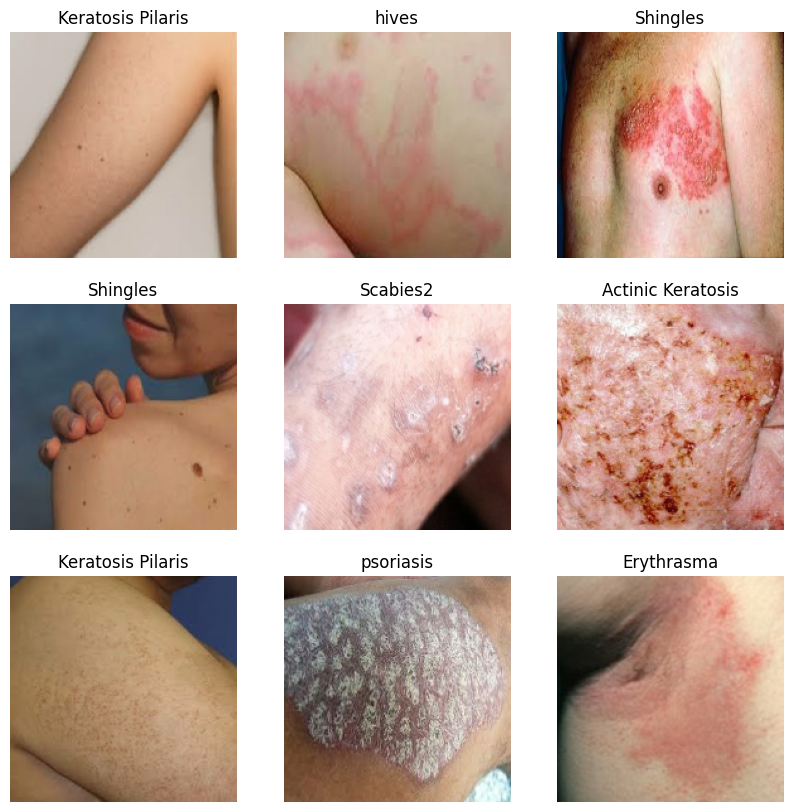

In [93]:
plt.figure(figsize=(10,10))
for image, labels in data_train.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(image[i].numpy().astype('uint8'))
        plt.title(data_cat[labels[i]])
        plt.axis('off')

In [94]:
data_train

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 180, 180, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [95]:
# model = Sequential([
#     layers.Rescaling(1./255),
#     layers.Conv2D(16, 3, padding='same', activation='relu'),
#     layers.MaxPooling2D(),
#     layers.Conv2D(32,3, padding='same',activation='relu'),
#     layers.MaxPooling2D(),
#     layers.Conv2D(64, 3, padding='same', activation='relu'),
#     layers.MaxPooling2D(),
#     layers.Flatten(),
#     layers.Dropout(0.2),
#     layers.Dense(128),
#     layers.Dense(len(data_cat))
                  
# ])


model = Sequential([
    data_augmentation,
    layers.Lambda(preprocess),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(num_classes, activation='softmax')
])

In [96]:
# model.compile(optimizer='adam', loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=['accuracy'])

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# model.summary()

In [97]:
# epochs_size = 25
# history = model.fit(data_train, validation_data=data_val, epochs=epochs_size)

epochs = 10

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

Epoch 1/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 56s 1s/step - accuracy: 0.1763 - loss: 3.2244 - val_accuracy: 0.3671 - val_loss: 2.2162
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 30s 833ms/step - accuracy: 0.4075 - loss: 2.0161 - val_accuracy: 0.4580 - val_loss: 1.8471
Epoch 3/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 31s 854ms/step - accuracy: 0.4668 - loss: 1.7241 - val_accuracy: 0.5070 - val_loss: 1.6986
Epoch 4/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 30s 843ms/step - accuracy: 0.5332 - loss: 1.5180 - val_accuracy: 0.5420 - val_loss: 1.5638
Epoch 5/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 31s 851ms/step - accuracy: 0.5750 - loss: 1.3579 - val_accuracy: 0.5559 - val_loss: 1.5033
Epoch 6/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 36s 1000ms/step - accuracy: 0.6178 - loss: 1.2468 - val_accuracy: 0.5699 - val_loss: 1.4615
Epoch 7/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 35s 962ms/step - accuracy: 0.6379 - loss: 1.1147 - val_accuracy: 0.5664 - val_loss: 1.4518
Epoch 8/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 32s 900ms/step - accuracy: 0.6562 - loss: 1.0382 - val_accura

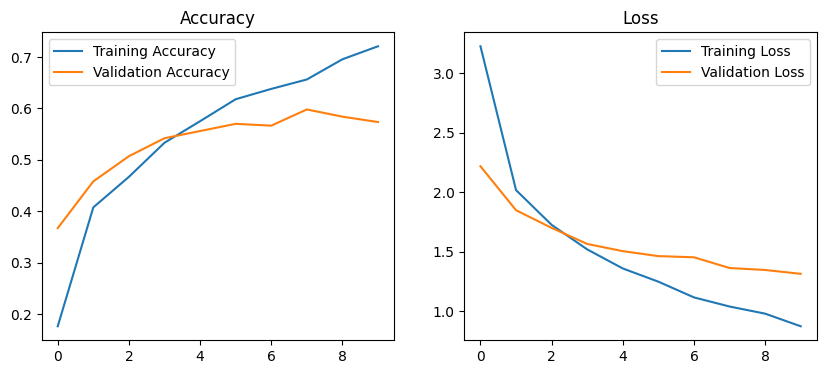

In [98]:
# epochs_range = range(epochs_size)
# plt.figure(figsize=(8,8))
# plt.subplot(1,2,1)
# plt.plot(epochs_range,history.history['accuracy'],label = 'Training Accuracy')
# plt.plot(epochs_range, history.history['val_accuracy'],label = 'Validation Accuracy')
# plt.title('Accuracy')

# plt.subplot(1,2,2)
# plt.plot(epochs_range,history.history['loss'],label = 'Training Loss')
# plt.plot(epochs_range, history.history['val_loss'],label = 'Validation Loss')
# plt.title('Loss')

acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]

loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs_range = range(epochs)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label="Training Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.legend()
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.legend()
plt.title("Loss")

plt.show()

In [99]:
# preds = model.predict(data_val)  # Running model on the validation dataset
# val_loss, val_acc = model.evaluate(data_val) # Obtaining Loss and Accuracy on the val dataset

# print('\nValidation Loss: ', val_loss)
# print('\nValidation Accuracy: ', np.round(val_acc * 100), '%')

val_loss, val_accuracy = model.evaluate(val_ds)
print(f"\nValidation Accuracy: {val_accuracy*100:.2f}%")

9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 692ms/step - accuracy: 0.5734 - loss: 1.3128

Validation Accuracy: 57.34%


In [100]:
# image = 'test_img2.jpeg'
# image = tf.keras.utils.load_img(image, target_size=(img_height,img_width))
# img_arr = tf.keras.utils.array_to_img(image)
# img_bat=tf.expand_dims(img_arr,0)

image_path = "test_img1.jpeg"   # <-- change if needed

img = tf.keras.utils.load_img(
    image_path,
    target_size=(img_height, img_width)
)

img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)
img_array = img_array / 255.0

predictions = model.predict(img_array)
predicted_class = data_cat[np.argmax(predictions)]
confidence = np.max(predictions) * 100

print(f"Prediction: {predicted_class}")
print(f"Confidence: {confidence:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Prediction: Chromhidrosis
Confidence: 45.22%


In [101]:
# predict = model.predict(img_bat)

In [102]:
# score = tf.nn.softmax(predict)

In [103]:
# print('Disease in image is {} with accuracy of {:0.2f}'.format(data_cat[np.argmax(score)],np.max(score)*100))